# Nama: Shabbir Fazle Mawla Yudhistira
# NIM: 25/566451/PA/23909

In [55]:
from PIL import Image
import numpy as np
import math
import matplotlib.pyplot as plt

In [56]:
img = Image.open("images.jpg")
matriksPCD = np.array(img)


# Downscaling Functions


In [57]:
def downscalemean(matriksPCD):
    height, width, channel = matriksPCD.shape
    hasild = np.zeros((height // 5, width // 5, 3), dtype=np.uint8)
    for y in range(height // 5):
        for x in range(width // 5):
            blok = matriksPCD[y*5:(y+1)*5, x*5:(x+1)*5]
            hasild[y,x] = np.mean(blok, axis=(0,1))
    return hasild

def downscalemax(matriksPCD):
    height, width, channel = matriksPCD.shape
    hasild = np.zeros((height // 5, width // 5,3), dtype=np.uint8)
    for y in range(height // 5):
        for x in range(width // 5):
            blok = matriksPCD[y*5:(y+1)*5, x*5:(x+1)*5]
            hasild[y,x] = np.max(blok, axis=(0,1))
    return hasild

def downscalemin(matriksPCD):
    height, width, channel = matriksPCD.shape
    hasild = np.zeros((height // 5, width // 5,3), dtype=np.uint8)
    for y in range(height // 5):
        for x in range(width // 5):
            blok = matriksPCD[y*5:(y+1)*5, x*5:(x+1)*5]
            hasild[y,x] = np.min(blok, axis=(0,1))
    return hasild

# Downscaling Results

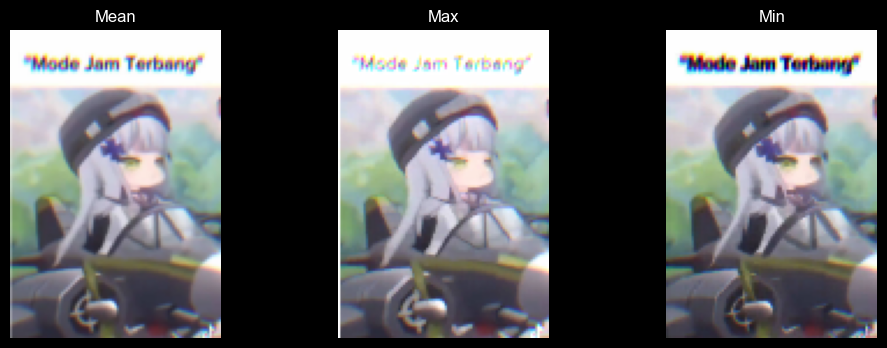

In [58]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(downscalemean(matriksPCD))
plt.axis("off")
plt.title("Mean")

plt.subplot(1, 3, 2)
plt.imshow(downscalemax(matriksPCD))
plt.axis("off")
plt.title("Max")

plt.subplot(1, 3, 3)
plt.imshow(downscalemin(matriksPCD))
plt.axis("off")
plt.title("Min")

plt.show()

# Upscaling Functions

In [59]:
def nearest(matriksPCD):
    height, width, channel = matriksPCD.shape
    new_width = 5 * width
    new_height = 5 * height
    hasilU = np.zeros((new_height, new_width, 3), dtype=np.uint8)
    for y in range(new_height):
        for x in range(new_width):
            source_x = x / 5
            source_y = y / 5
            if(source_x - math.floor(source_x) < 0.5):
                source_x = math.floor(source_x)
            else:
                source_x = math.ceil(source_x)
            if(source_y - math.floor(source_y) < 0.5):
                source_y = math.floor(source_y)
            else:
                source_y = math.ceil(source_y)
            source_x = min(source_x, width - 1)
            source_y = min(source_y, height - 1)
            hasilU[y,x] = matriksPCD[source_y,source_x]
    return hasilU

def bilinear(matriksPCD):
    height, width, channel = matriksPCD.shape
    new_width = 5 * width
    new_height = 5 * height
    hasilU = np.zeros((new_height, new_width, 3), dtype=np.uint8)
    for y in range(new_height):
        for x in range(new_width):
            source_x = x / 5
            source_y = y / 5
            xnear1 = math.floor(source_x)
            ynear1 = math.floor(source_y)
            xnear2 = min(math.ceil(source_x), width - 1)
            ynear2 = min(math.ceil(source_y), height - 1)
            pojok_kiri_bawah = matriksPCD[ynear2,xnear1]
            pojok_kiri_atas = matriksPCD[ynear1,xnear1]
            pojok_kanan_bawah = matriksPCD[ynear2, xnear2]
            pojok_kanan_atas = matriksPCD[ynear1, xnear2]
            dx = source_x - xnear1
            dy = source_y - ynear1
            atas = pojok_kiri_atas * (1 - dx) + pojok_kanan_atas * dx
            bawah = pojok_kiri_bawah * (1 - dx) + pojok_kanan_bawah * dx
            hasilU[y,x] = atas * (1 - dy) + bawah * dy
    return hasilU

def cubic(p0,p1,p2,p3, t):
    return 0.5 * (2*p1 + (-p0+p2)*t + (2*p0 - 5*p1 + 4*p2 - p3)*t**2 + (-p0 + 3*p1 - 3*p2 + p3)*t**3)

def bicubic(matriksPCD):
    matriksPCD = matriksPCD.astype(np.float64)
    height, width, channel = matriksPCD.shape
    new_width = 5 * width
    new_height = 5 * height
    hasilU = np.zeros((new_height, new_width, 3), dtype=np.uint8)
    for y in range(new_height):
        for x in range(new_width):
            source_x = x / 5
            source_y = y / 5
            xnear = math.floor(source_x)
            ynear = math.floor(source_y)
            anggota_xnear = [max(xnear -1, 0), xnear, min(xnear +1, width - 1), min(xnear + 2, width -1)]
            anggota_ynear = [max(ynear -1,0), ynear, min(ynear+1, height-1), min(ynear+2, height-1)]
            dx = source_x - xnear
            dy = source_y - ynear
            hasil_x = []
            for i in range(4):
                p0 = matriksPCD[anggota_ynear[i], anggota_xnear[0]]
                p1 = matriksPCD[anggota_ynear[i], anggota_xnear[1]]
                p2 = matriksPCD[anggota_ynear[i], anggota_xnear[2]]
                p3 = matriksPCD[anggota_ynear[i], anggota_xnear[3]]
                nilai = cubic(p0,p1,p2,p3,dx)
                hasil_x.append(nilai)
            hasil = cubic(hasil_x[0],hasil_x[1],hasil_x[2],hasil_x[3],dy)
            hasilU[y,x] = np.clip(hasil, 0, 255)
    return hasilU



# Upscaling Results

Text(0.5, 1.0, 'upscaled bicubic Mean')

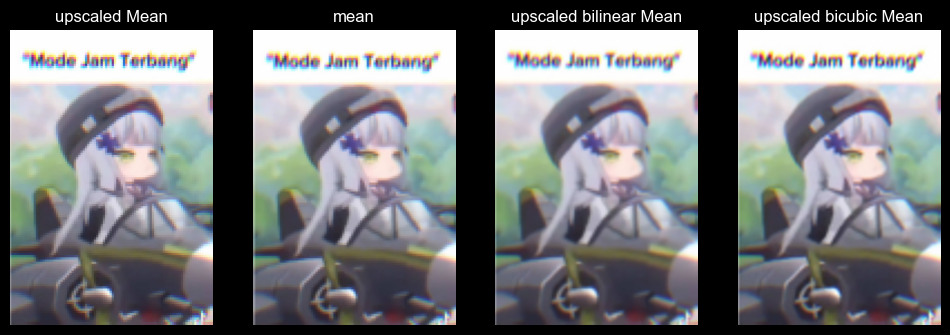

In [60]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(nearest(downscalemean(matriksPCD)))
plt.axis("off")
plt.title("upscaled Mean")

plt.subplot(1, 4, 2)
plt.imshow(downscalemean(matriksPCD))
plt.axis("off")
plt.title("mean")

plt.subplot(1, 4, 3)
plt.imshow(bilinear(downscalemean(matriksPCD)))
plt.axis("off")
plt.title("upscaled bilinear Mean")

plt.subplot(1, 4, 4)
plt.imshow(bicubic(downscalemean(matriksPCD)))
plt.axis("off")
plt.title("upscaled bicubic Mean")
